In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency, f_oneway

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', None)  

In [3]:
df = pd.read_csv('C:/Users/xavis/Xavier/Benestar-e/DATA/DADES_EXCEL_TOTS.csv', sep=';', encoding='latin1')
print(df.shape)
df.head()

(1778, 250)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic, )_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic, )_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,\nTranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100
0,1.0,1.0,18.0,1.0,1.0,1.0,4.0,2.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,21.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,6.0,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,4.0,3.0,4.0,4.0,5.0,4.0,5.0,5.0,3.0,4.0,3.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,3.0,3.0,4.0,5.0,4.0,2.0,4.0,5.0,5.0,4.0,5.0,4.0,4.0,44.0,38.0,28.0,27.0,137.0,2.0,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
## split by student groups
students = df[df['GRUP'] == 1]
print(students.shape)
students.head()

(450, 250)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic, )_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic, )_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,\nTranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100
0,1.0,1.0,18.0,1.0,1.0,1.0,4.0,2.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,21.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,6.0,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,4.0,3.0,4.0,4.0,5.0,4.0,5.0,5.0,3.0,4.0,3.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,3.0,3.0,4.0,5.0,4.0,2.0,4.0,5.0,5.0,4.0,5.0,4.0,4.0,44.0,38.0,28.0,27.0,137.0,2.0,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
## Define the columns to analyze for collinearity
metric_cols = ['ID', 'BSI_NO_IGS_PT_N100', 'NO_Agotament_emocional_N100', 'NO_Cinisme_N100', 'Realizació_personal_N100', 'SEEIT_PT_N100', 'SWLS_PT_N100']

In [6]:
## Extract the dataframe for the selected metrics
students = students[metric_cols]
print(students.shape)
students.head()

(450, 7)


,ID,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,Realizació_personal_N100,SEEIT_PT_N100,SWLS_PT_N100
0,1.0,61.904762,96.666667,100.000000,94.444444,78.79,87.0
1,2.0,36.956522,40.000000,87.500000,86.111111,51.52,47.0
2,3.0,41.304348,20.000000,87.500000,86.111111,71.21,47.0
13,14.0,26.190476,30.000000,54.166667,63.888889,63.64,80.0
14,15.0,57.142857,90.000000,58.333333,72.222222,70.45,70.0


In [7]:
print("Proportion of NaN per column:")
print(students.drop(columns=['ID']).isna().mean().round(3)*100)

Proportion of NaN per column:
BSI_NO_IGS_PT_N100              1.8
NO_Agotament_emocional_N100    11.1
NO_Cinisme_N100                11.1
Realizació_personal_N100       11.1
SEEIT_PT_N100                   0.0
SWLS_PT_N100                   16.4
dtype: float64


In [8]:
## Remove rows with NaN in any of the metric columns (except ID)

cols_sin_id = [col for col in students.columns if col != 'ID']
students_df = students.dropna(subset=cols_sin_id)
print(f"Number of rows removed: {students.shape[0] - students_df.shape[0]}")
print(students_df.shape)
students_df.head()

Number of rows removed: 82
(368, 7)


,ID,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,Realizació_personal_N100,SEEIT_PT_N100,SWLS_PT_N100
0,1.0,61.904762,96.666667,100.000000,94.444444,78.79,87.0
1,2.0,36.956522,40.000000,87.500000,86.111111,51.52,47.0
2,3.0,41.304348,20.000000,87.500000,86.111111,71.21,47.0
13,14.0,26.190476,30.000000,54.166667,63.888889,63.64,80.0
14,15.0,57.142857,90.000000,58.333333,72.222222,70.45,70.0


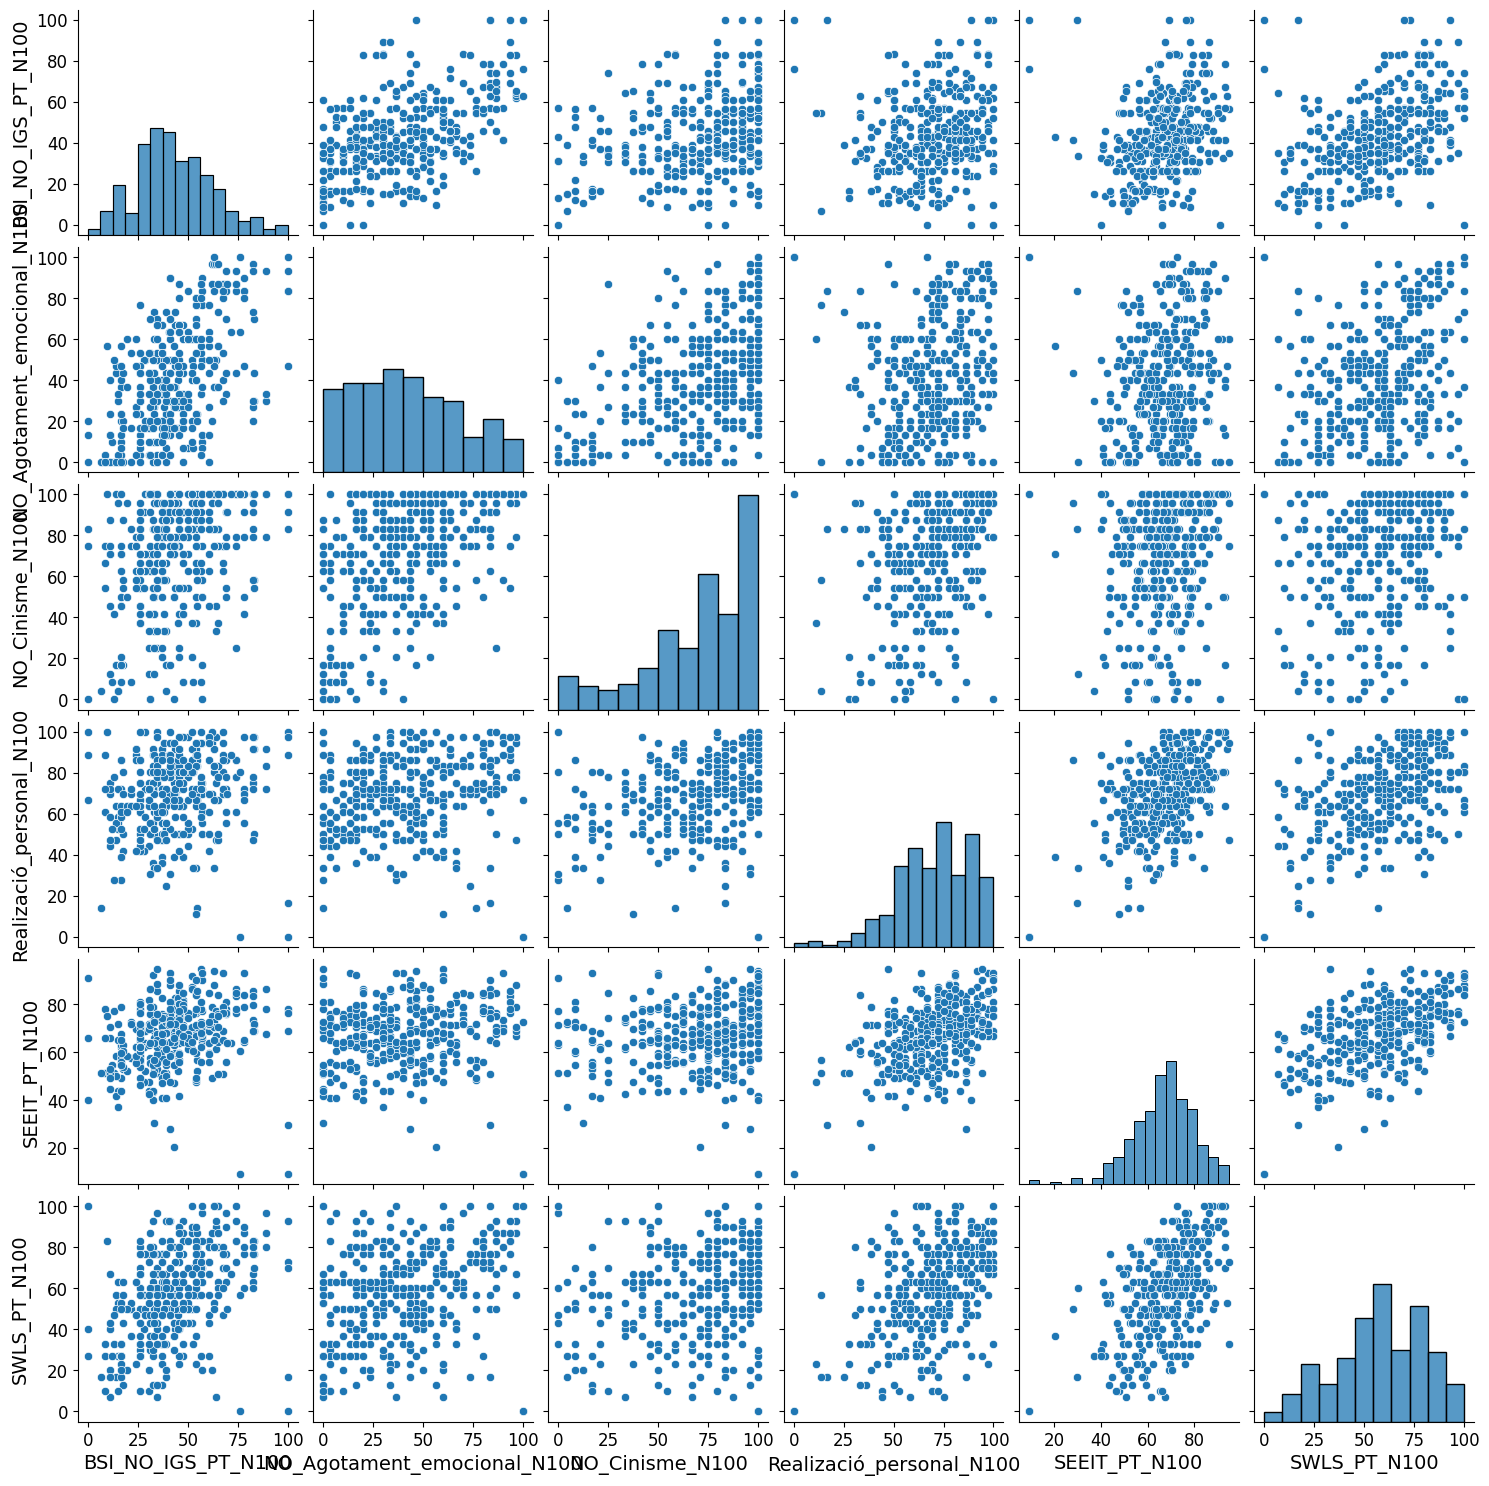

In [9]:
## Pairplot for numeric variables
numericas = [col for col in students_df.columns if  col in students_df and col != 'ID']

cols = [col for col in students_df[numericas]]
g = sns.pairplot(students_df[cols])

for ax in g.axes.flatten():
    plt.setp(ax.get_xticklabels(), fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=12)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)  
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)


In [10]:
## detecting multicollinearity for numeric variables

def detectar_multicolinearidad_numericas(df, numericas, threshold=0.99):
    print("=== DETECTION OF MULTICOLLINEARITY (Spearman) ===")
    print(f"Numeric variables: {len(numericas)}")

    resultados = {
        'numerica_numerica': [],
        'variables_a_eliminar': []
    }

    # 1. NUMERIC vs NUMERIC (perfect correlation)
    print("\n=== 1. REDUNDANT NUMERIC VARIABLES ===")
    if len(numericas) > 1:
        corr_matrix = df[numericas].corr(method='spearman')  
        for i in range(len(numericas)):
            for j in range(i+1, len(numericas)):
                corr_value = corr_matrix.iloc[i, j]
                if abs(corr_value) >= threshold:  # Almost perfect correlation
                    var1 = numericas[i]
                    var2 = numericas[j]
                    resultados['numerica_numerica'].append({
                        'Variable_1': var1,
                        'Variable_2': var2,
                        'Correlacion': corr_value
                    })
                    print(f"  • {var1} ↔ {var2}: r = {corr_value:.3f}")

    # 2. CREATE LIST OF VARIABLES TO REMOVE
    variables_a_eliminar = []
    for par in resultados['numerica_numerica']:
        if par['Variable_2'] not in variables_a_eliminar:
            variables_a_eliminar.append(par['Variable_2'])

    print(f"\n=== FINAL SUMMARY ===")
    print(f"Original variables: {len(df.columns)}")
    print(f"  - Numeric: {len(numericas)}")
    print(f"Redundant variables found: {len(variables_a_eliminar)}")
    print(f"Final variables: {len(df.columns) - len(variables_a_eliminar)}")

    if variables_a_eliminar:
        print(f"\nVariables to remove:")
        for var in variables_a_eliminar:
            print(f"  - {var}")

    resultados['variables_a_eliminar'] = variables_a_eliminar
    return resultados

# Run the function only with numeric variables
resultados_multicolinearidad = detectar_multicolinearidad_numericas(students_df, numericas)

=== DETECTION OF MULTICOLLINEARITY (Spearman) ===
Numeric variables: 6

=== 1. REDUNDANT NUMERIC VARIABLES ===

=== FINAL SUMMARY ===
Original variables: 7
  - Numeric: 6
Redundant variables found: 0
Final variables: 7


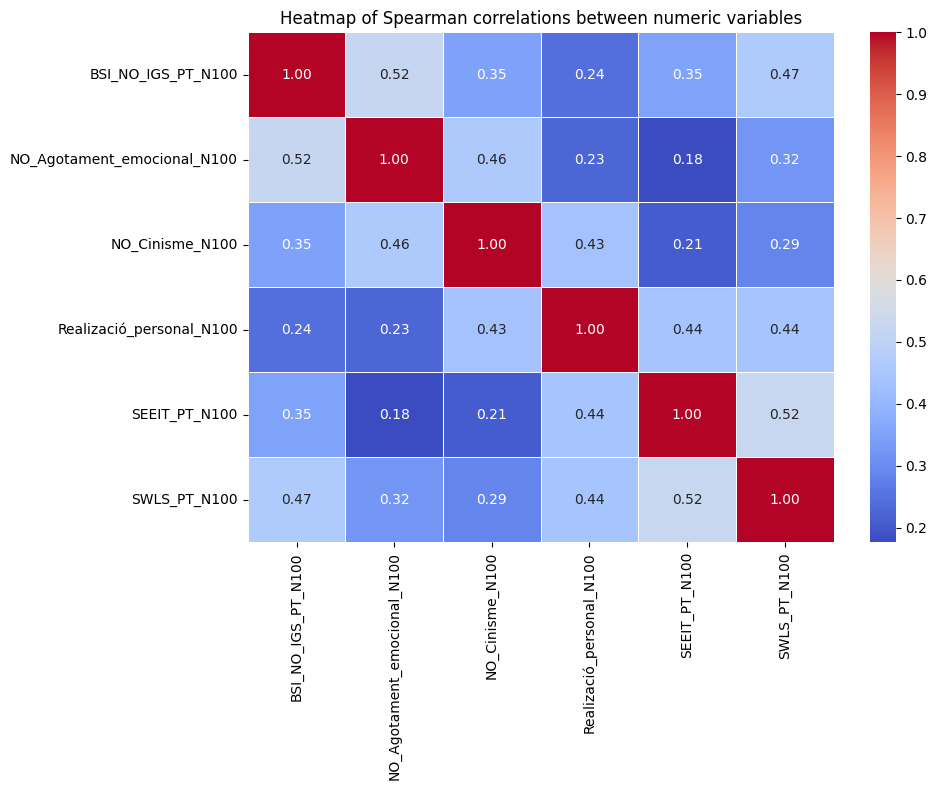

In [11]:
# Calculate the Spearman correlation matrix
corr_matrix = students_df[numericas].corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Spearman correlations between numeric variables')
plt.tight_layout()
plt.show()

In [12]:
## Descriptive analysis with outlier detection for numeric variables

def advanced_descriptive_analysis(df, numericas):
    print("=== ADVANCED DESCRIPTIVE ANALYSIS ===")
    
    vars_num = df[numericas]
    
    if len(vars_num.columns) > 0:
        print(f"\n--- NUMERIC VARIABLES ({len(vars_num.columns)}) ---")
        print("\n--- OUTLIER DETECTION ---")
        for col in vars_num.columns:
            Q1 = vars_num[col].quantile(0.2)
            Q3 = vars_num[col].quantile(0.8)
            IQR = Q3 - Q1
            outliers = vars_num[(vars_num[col] < Q1 - 1.5*IQR) | (vars_num[col] > Q3 + 1.5*IQR)]
            print()
            print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(vars_num)*100:.1f}%)")
            # Search for IDs in the original DataFrame if not in vars_num
            if len(outliers) > 0:
                if 'ID' in outliers.columns:
                    ids_out = outliers['ID'].tolist()
                elif 'ID' in df.columns:
                    ids_out = df.loc[outliers.index, 'ID'].tolist()
                else:
                    ids_out = []
                print("  IDs con outlier:")
                print(ids_out)
                print()

# Before calling the function, make sure 'ID' is in students_df
if 'ID' in students.columns and 'ID' not in students_df.columns:
    students_df['ID'] = students['ID']

advanced_descriptive_analysis(students_df, numericas)

=== ADVANCED DESCRIPTIVE ANALYSIS ===

--- NUMERIC VARIABLES (6) ---

--- OUTLIER DETECTION ---

BSI_NO_IGS_PT_N100: 0 outliers (0.0%)

NO_Agotament_emocional_N100: 0 outliers (0.0%)

NO_Cinisme_N100: 0 outliers (0.0%)

Realizació_personal_N100: 2 outliers (0.5%)
  IDs con outlier:
[276.0, 743.0]


SEEIT_PT_N100: 3 outliers (0.8%)
  IDs con outlier:
[276.0, 518.0, 743.0]


SWLS_PT_N100: 0 outliers (0.0%)


In [13]:
## Identify IDs that are outliers in more than one variable

from collections import Counter, defaultdict

def repeated_outlier_ids(df, numericas):
    from collections import defaultdict
    id_vars = defaultdict(list)
    for col in numericas:
        if col in df.columns:
            Q1 = df[col].quantile(0.20)
            Q3 = df[col].quantile(0.80)
            IQR = Q3 - Q1
            outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
            if 'ID' in outliers.columns:
                for id_ in outliers['ID']:
                    id_vars[id_].append(col)
    repeated_ids = {k: v for k, v in id_vars.items() if len(v) > 1}
    print("IDs that appear as outliers in more than one variable:")
    if repeated_ids:
        for id_, vars_ in repeated_ids.items():
            print(f"ID: {id_} - {len(vars_)} times - Variables: {vars_}")
        return repeated_ids
    else:
        print("No outliers.")
        return None

# Run the function
repeated_outlier_ids(students_df, cols)
outliers_grup_1 = repeated_outlier_ids(students_df, cols)


IDs that appear as outliers in more than one variable:
ID: 276.0 - 2 times - Variables: ['Realizació_personal_N100', 'SEEIT_PT_N100']
ID: 743.0 - 2 times - Variables: ['Realizació_personal_N100', 'SEEIT_PT_N100']
IDs that appear as outliers in more than one variable:
ID: 276.0 - 2 times - Variables: ['Realizació_personal_N100', 'SEEIT_PT_N100']
ID: 743.0 - 2 times - Variables: ['Realizació_personal_N100', 'SEEIT_PT_N100']


In [14]:
## POSSIBLE OUTLIERS

ids_interes = [276, 743]
variables = [col for col in students_df.columns if col not in ['ID']]

df_resto = students_df[~students_df['ID'].isin(ids_interes)]
media_resto = df_resto[variables].mean()
std_resto = df_resto[variables].std()

# Build comparison table by variable and by ID
comparacion = pd.DataFrame()

for id_ in ids_interes:
    datos_id = students_df[students_df['ID'] == id_][variables].iloc[0]
    fila = pd.DataFrame({
        'ID': id_,
        'Variable': variables,
        'Valor_ID': datos_id.values,
        'Media_Resto': media_resto.values,
        'STD_Resto': std_resto.values
    })
    comparacion = pd.concat([comparacion, fila], ignore_index=True)

comparacion

,ID,Variable,Valor_ID,Media_Resto,STD_Resto
0,276,BSI_NO_IGS_PT_N100,76.190476,43.271222,18.869892
1,276,NO_Agotament_emocional_N100,100.000000,40.373406,26.084050
2,276,NO_Cinisme_N100,100.000000,69.626594,26.951338
3,276,Realizació_personal_N100,0.000000,70.226169,18.005588
4,276,SEEIT_PT_N100,9.090000,67.329098,12.613899
5,276,SWLS_PT_N100,0.000000,58.308743,22.006606
6,743,BSI_NO_IGS_PT_N100,100.000000,43.271222,18.869892
7,743,NO_Agotament_emocional_N100,100.000000,40.373406,26.084050
8,743,NO_Cinisme_N100,100.000000,69.626594,26.951338
9,743,Realizació_personal_N100,0.000000,70.226169,18.005588


Justification for Retaining Outliers

Minimal prevalence. Only 0.5–0.8% of the 368 subjects were flagged as outliers across 2 of 6 variables, posing no meaningful distributional threat.

Clinical validity. IDs 276 and 743 show an internally coherent extreme profile (emotional exhaustion = 100, cynicism = 100, personal accomplishment = 0, life satisfaction = 0, empathy = 9.09). These values are clinically plausible and reflect genuine cases of severe burnout rather than measurement error.

Substantive relevance. Removing them would introduce a systematic bias toward moderate wellbeing profiles, precisely at the vulnerable end of the spectrum that the study aims to characterize.

Method robustness. LCA relies on maximum likelihood estimation, which is inherently more robust to extreme values than distance-based methods such as k-means. The probabilistic framework assigns these cases to the most appropriate latent class without distorting the global solution.

Conservative IQR criterion. Outlier detection used the 20th–80th percentile range instead of the standard 25th–75th, making the fence more stringent and likely to flag legitimate distributional extremes rather than true anomalies.